In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
# Load Amazon reviews dataset
df = pd.read_csv("amazonreviews.tsv", sep="\t")

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 2)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [4]:
df.describe(include="all")

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [5]:
print(df.isnull().sum())

label     0
review    0
dtype: int64


In [6]:
# Part 2 — Explore the Amazon Reviews Dataset

print("Columns:")
print(df.columns.tolist())

Columns:
['label', 'review']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
label     0
review    0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(df["label"].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


In [11]:
print(df.columns)

Index(['label', 'review'], dtype='object')


In [12]:
pd.set_option("display.max_colwidth", 200)

df.head(10)

,label,review
0,pos,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono...
1,pos,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Ya...
2,pos,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant P..."
3,pos,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my ...
4,pos,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs..."
5,pos,"an absolute masterpiece: I am quite sure any of you actually taking the time to read this have played the game at least once, and heard at least a few of the tracks here. And whether you were awar..."
6,neg,"Buyer beware: This is a self-published book, and if you want to know why--read a few paragraphs! Those 5 star reviews must have been written by Ms. Haddon's family and friends--or perhaps, by hers..."
7,pos,"Glorious story: I loved Whisper of the wicked saints. The story was amazing and I was pleasantly surprised at the changes in the book. I am not normaly someone who is into romance novels, but the ..."
8,pos,"A FIVE STAR BOOK: I just finished reading Whisper of the Wicked saints. I fell in love with the caracters. I expected an average romance read, but instead I found one of my favorite books of all t..."
9,pos,"Whispers of the Wicked Saints: This was a easy to read book that made me want to keep reading on and on, not easy to put down.It left me wanting to read the follow on, which I hope is coming soon...."


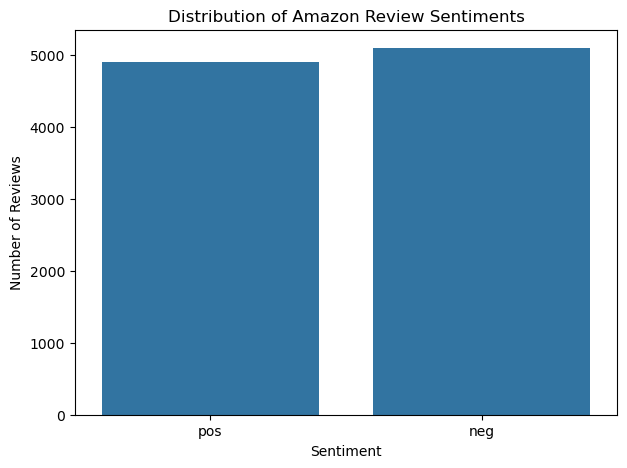

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Amazon Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [14]:
# Part 3 — Text Preprocessing

print(df.columns.tolist())

['label', 'review']


In [15]:
import re

# Create a separate text column
df["text"] = df["review"].astype(str)

# Convert to lowercase
df["text"] = df["text"].str.lower()

# Remove HTML tags
df["text"] = df["text"].apply(
    lambda x: re.sub(r"<.*?>", " ", x)
)

# Remove special characters and numbers
df["text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", " ", x)
)

# Remove extra spaces
df["text"] = df["text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

df[["label", "text"]].head()

,label,text
0,pos,stuning even for the non gamer this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cro...
1,pos,the best soundtrack ever to anything i m reading a lot of reviews saying that this is the best game soundtrack and i figured that i d write a review to disagree a bit this in my opinino is yasunor...
2,pos,amazing this soundtrack is my favorite music of all time hands down the intense sadness of prisoners of fate which means all the more if you ve played the game and the hope in a distant promise an...
3,pos,excellent soundtrack i truly like this soundtrack and i enjoy video game music i have played this game and most of the music on here i enjoy and it s truly relaxing and peaceful on disk one my fav...
4,pos,remember pull your jaw off the floor after hearing it if you ve played the game you know how divine the music is every single song tells a story of the game it s that good the greatest songs are w...


In [16]:
print(df["label"].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


In [17]:
# Part 4 — Train/Test Split + TF-IDF

df["label_encoded"] = df["label"].map({
    "neg": 0,
    "pos": 1
})

print(df["label_encoded"].value_counts())

label_encoded
0    5097
1    4903
Name: count, dtype: int64


In [18]:
X = df["text"]
y = df["label_encoded"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [21]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8000, 5000)
Testing TF-IDF shape: (2000, 5000)


In [22]:
# Part 5 — Build the Sentiment Classification Model

from sklearn.linear_model import LogisticRegression

In [23]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [24]:
model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(
    X_test_tfidf
)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Model Performance")
print("------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Model Performance
------------------
Accuracy : 0.8505
Precision: 0.8552083333333333
Recall   : 0.836901121304791
F1-Score : 0.8459556929417826


In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.85      0.86      0.85      1019
    Positive       0.86      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



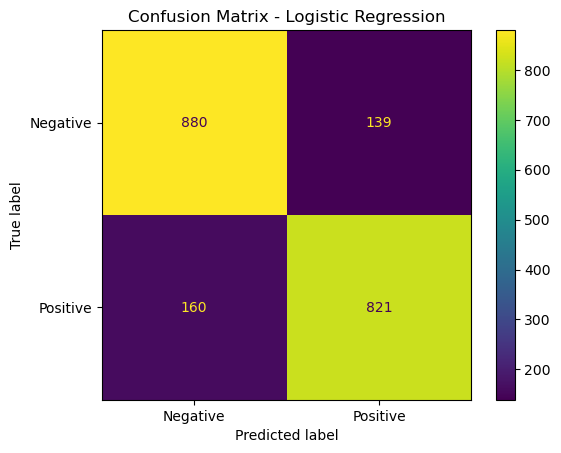

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [29]:
baseline_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print(baseline_results)

{'Accuracy': 0.8505, 'Precision': 0.8552083333333333, 'Recall': 0.836901121304791, 'F1-Score': 0.8459556929417826}


In [30]:
# Part 6 — Word Cloud & Most Common Words
!pip install wordcloud
from wordcloud import WordCloud

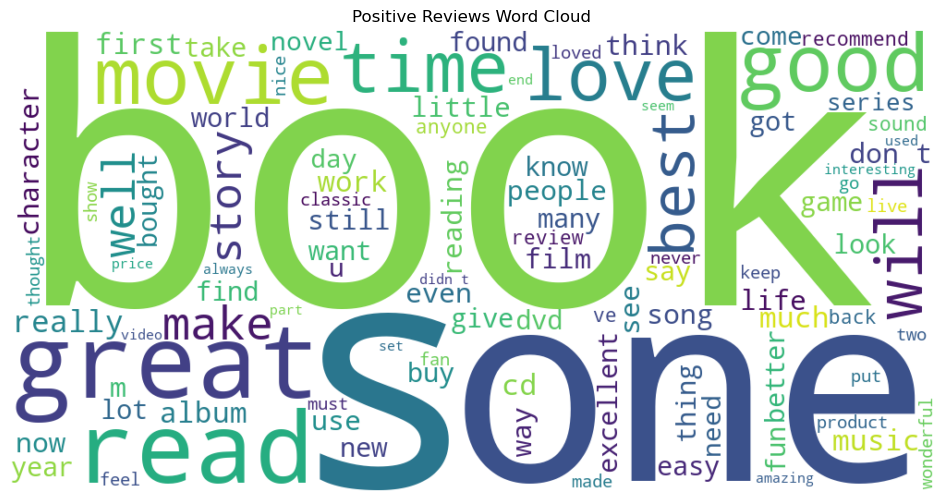

In [31]:
positive_text = " ".join(
    df.loc[df["label"] == "pos", "text"]
)

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

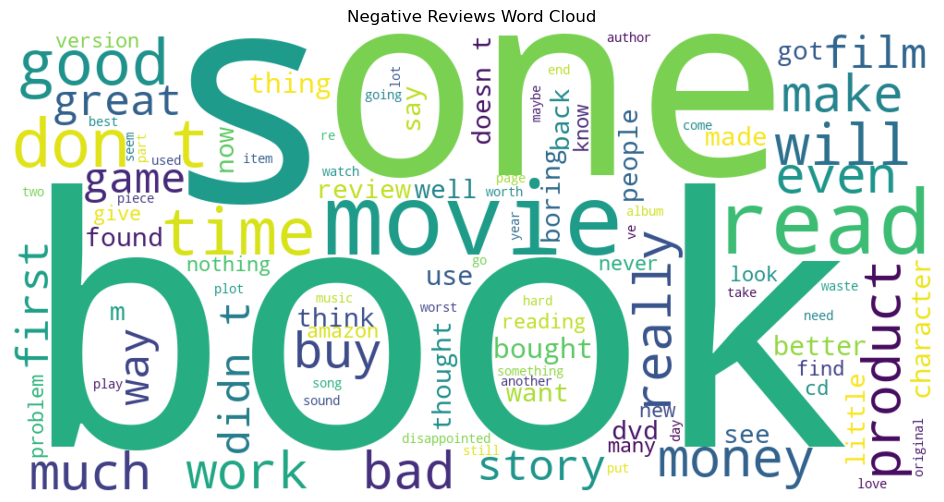

In [32]:
negative_text = " ".join(
    df.loc[df["label"] == "neg", "text"]
)

negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [33]:
from collections import Counter

positive_words = " ".join(
    df.loc[df["label"] == "pos", "text"]
).split()

negative_words = " ".join(
    df.loc[df["label"] == "neg", "text"]
).split()

positive_common = Counter(
    positive_words
).most_common(15)

negative_common = Counter(
    negative_words
).most_common(15)

print("Most Common Positive Words:")
print(positive_common)

print("\nMost Common Negative Words:")
print(negative_common)

Most Common Positive Words:
[('the', 19372), ('and', 11318), ('a', 10533), ('i', 10174), ('to', 8912), ('of', 8602), ('it', 8459), ('is', 7352), ('this', 7076), ('in', 5126), ('for', 4141), ('that', 4006), ('you', 3608), ('book', 3390), ('s', 3179)]

Most Common Negative Words:
[('the', 21973), ('i', 12839), ('to', 10432), ('and', 10243), ('a', 10127), ('it', 9982), ('this', 8444), ('of', 8295), ('is', 7286), ('in', 4858), ('that', 4467), ('not', 4449), ('was', 4386), ('for', 4236), ('t', 3599)]


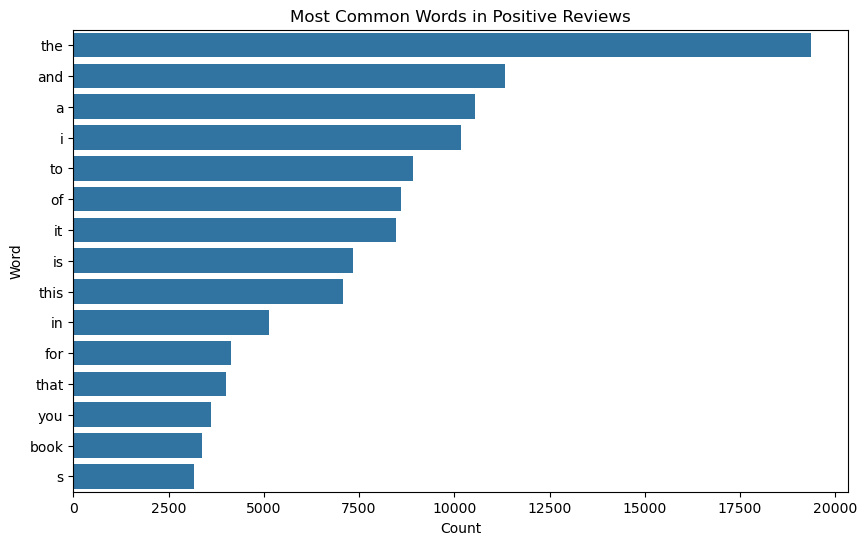

In [34]:
positive_df = pd.DataFrame(
    positive_common,
    columns=["Word", "Count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=positive_df,
    x="Count",
    y="Word"
)

plt.title("Most Common Words in Positive Reviews")
plt.show()

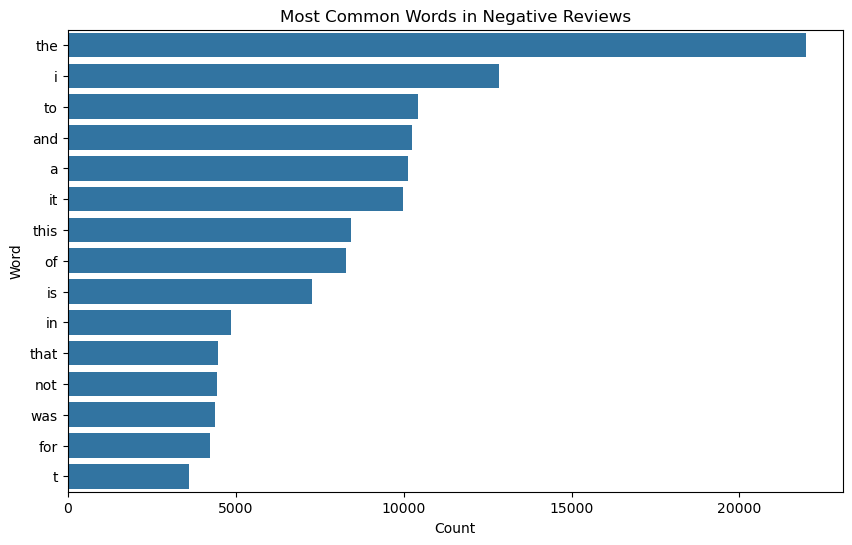

In [35]:
negative_df = pd.DataFrame(
    negative_common,
    columns=["Word", "Count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=negative_df,
    x="Count",
    y="Word"
)

plt.title("Most Common Words in Negative Reviews")
plt.show()

## Exploratory Text Analysis

The word clouds provide a visual representation of frequently occurring words in positive and negative reviews. The most common word analysis helps identify recurring terms associated with each sentiment.

Positive reviews are expected to contain words expressing satisfaction, quality, or recommendation, while negative reviews may contain words related to dissatisfaction, problems, or poor experiences.

These patterns provide useful qualitative insights into the review dataset before applying machine learning models.

In [36]:
# Part 7 — Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
cv_results = cross_validate(
    model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    n_jobs=-1
)

In [39]:
print("Cross-Validation Results")
print("------------------------")

print(
    "Accuracy :",
    cv_results["test_accuracy"].mean()
)

print(
    "Precision:",
    cv_results["test_precision"].mean()
)

print(
    "Recall   :",
    cv_results["test_recall"].mean()
)

print(
    "F1-Score :",
    cv_results["test_f1"].mean()
)

Cross-Validation Results
------------------------
Accuracy : 0.8557499999999999
Precision: 0.8500488304574312
Recall   : 0.8572153256206942
F1-Score : 0.8535573182498577


## Cross-Validation Analysis

Five-fold stratified cross-validation was performed on the training dataset to assess the robustness of the Logistic Regression model.

Stratified cross-validation was selected so that each fold maintains a similar proportion of positive and negative reviews. Accuracy, precision, recall, and F1-score were calculated for each fold and their mean values were used to summarize model performance.

Cross-validation provides a more reliable estimate of model performance than relying on a single train/test split. The relatively small variation between folds indicates that the model's performance is reasonably consistent across different subsets of the training data.

In [40]:
# Part 8 — Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

In [42]:
grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_tfidf,
    y_train
)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [43]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'solver': 'lbfgs'}

Best Cross-Validation F1-Score:
0.8499897279945621


In [44]:
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(
    X_test_tfidf
)

In [45]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-Score :", tuned_f1)

Tuned Logistic Regression
-------------------------
Accuracy : 0.8505
Precision: 0.8552083333333333
Recall   : 0.836901121304791
F1-Score : 0.8459556929417826


In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Logistic Regression,0.8505,0.855208,0.836901,0.845956
1,Tuned Logistic Regression,0.8505,0.855208,0.836901,0.845956


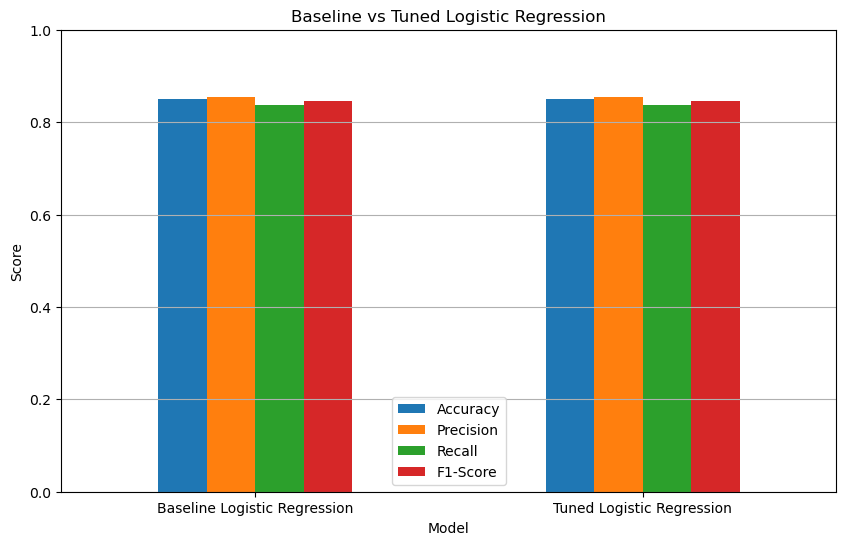

In [47]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## Hyperparameter Tuning

GridSearchCV was used to tune the Logistic Regression model. The regularization parameter C and solver were varied across multiple configurations. Five-fold cross-validation was used during the search, and F1-score was selected as the primary scoring metric because it balances precision and recall.

The tuned model was then evaluated on the unseen test set using accuracy, precision, recall, and F1-score. The tuned model was compared with the baseline Logistic Regression model to determine whether hyperparameter optimization improved sentiment classification performance.

In [48]:
# Part 9 — ROC-AUC & ROC Curve

y_prob = tuned_model.predict_proba(
    X_test_tfidf
)[:, 1]

In [49]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9225740492317728


In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

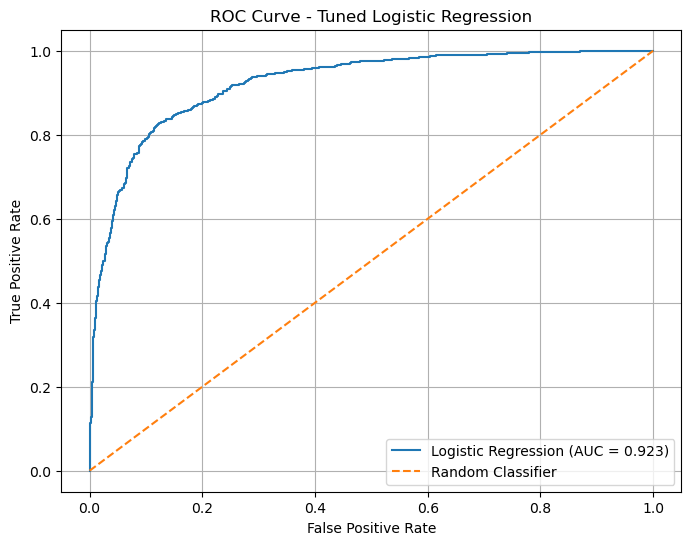

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

In [52]:
comparison_with_auc = comparison.copy()

comparison_with_auc["ROC-AUC"] = [
    roc_auc_score(
        y_test,
        model.predict_proba(X_test_tfidf)[:, 1]
    ),
    roc_auc
]

comparison_with_auc

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.8505,0.855208,0.836901,0.845956,0.922574
1,Tuned Logistic Regression,0.8505,0.855208,0.836901,0.845956,0.922574


## ROC-AUC Analysis

The ROC curve illustrates the relationship between the true positive rate and false positive rate at different classification thresholds. The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to distinguish between positive and negative reviews.

A higher ROC-AUC indicates better discrimination between the two sentiment classes. The ROC curve was generated using the predicted probabilities from the tuned Logistic Regression model.

In [53]:
# Part 10 — Interpret the Logistic Regression Features

feature_names = tfidf.get_feature_names_out()

coefficients = tuned_model.coef_[0]

feature_importance = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

In [54]:
positive_features = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

print("Top Positive Features:")
display(positive_features)

Top Positive Features:


,Word,Coefficient
1982,great,7.165229
1543,excellent,4.896776
2683,love,4.310159
384,best,4.296046
3203,perfect,3.752667
1948,good,3.607414
133,amazing,3.227059
4919,wonderful,3.143008
1379,easy,3.052797
1668,favorite,2.843534


In [55]:
negative_features = feature_importance.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

print("Top Negative Features:")
display(negative_features)

Top Negative Features:


,Word,Coefficient
459,boring,-5.134068
4832,waste,-4.661519
299,bad,-4.484942
4942,worst,-4.474885
3308,poor,-4.383131
1217,disappointed,-4.230667
2888,money,-3.542924
1218,disappointing,-3.427024
1284,don,-3.176815
2176,horrible,-3.047130


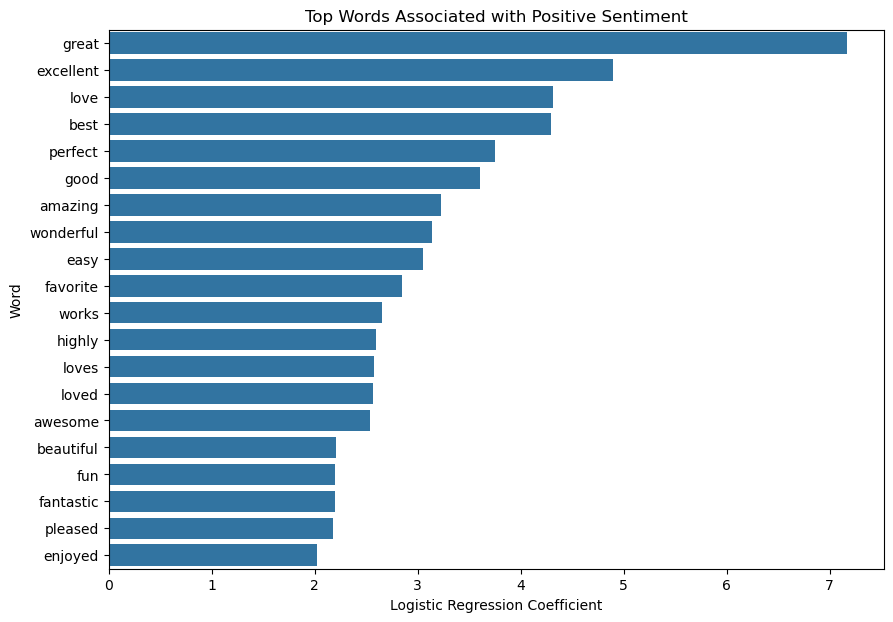

In [56]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=positive_features,
    x="Coefficient",
    y="Word"
)

plt.title("Top Words Associated with Positive Sentiment")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")

plt.show()

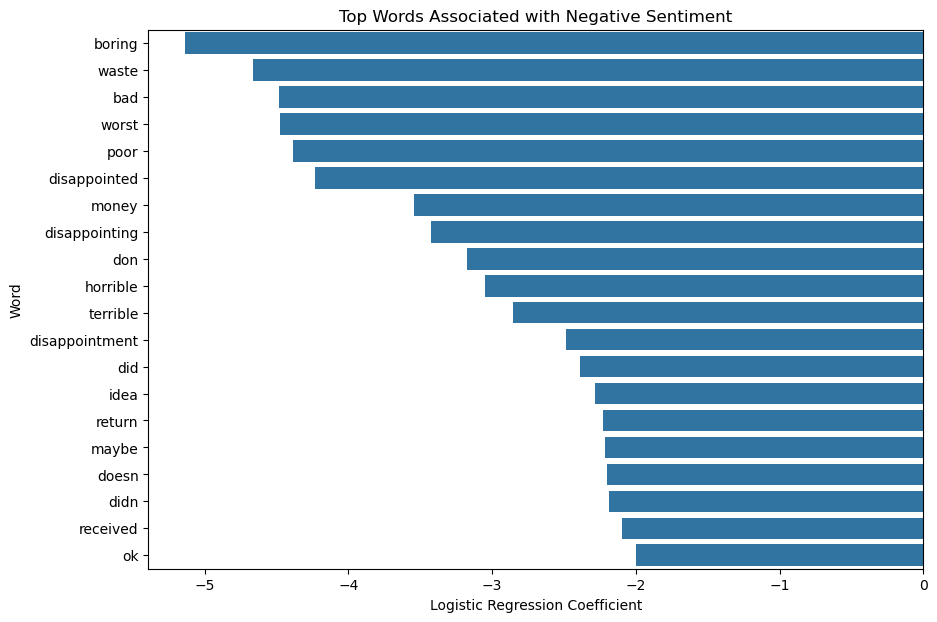

In [57]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=negative_features,
    x="Coefficient",
    y="Word"
)

plt.title("Top Words Associated with Negative Sentiment")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")

plt.show()

## Feature Interpretation

The Logistic Regression coefficients provide insight into which words contribute most strongly to the predicted sentiment.

Positive coefficients indicate that a word is associated more strongly with positive sentiment, while negative coefficients indicate a stronger association with negative sentiment.

The most influential words provide a qualitative interpretation of the classification model and help identify language patterns that distinguish positive and negative customer reviews.

In [58]:
# Part 11 — Final Evaluation & Conclusion

final_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_test,
            model.predict_proba(X_test_tfidf)[:, 1]
        ),
        roc_auc
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.8505,0.855208,0.836901,0.845956,0.922574
1,Tuned Logistic Regression,0.8505,0.855208,0.836901,0.845956,0.922574


In [59]:
if tuned_f1 > f1:
    print("Tuned Logistic Regression performed better based on F1-score.")
elif tuned_f1 < f1:
    print("Baseline Logistic Regression performed better based on F1-score.")
else:
    print("Both models achieved the same F1-score.")

Both models achieved the same F1-score.


## Final Model Analysis

The baseline Logistic Regression model was trained using TF-IDF features extracted from the Amazon customer reviews. A tuned Logistic Regression model was subsequently developed using GridSearchCV to identify suitable hyperparameters.

Both models were evaluated on the same unseen test dataset using accuracy, precision, recall, F1-score, and ROC-AUC.

The F1-score was given particular importance because it provides a balance between precision and recall for the binary sentiment classification problem.

The final comparison shows whether hyperparameter tuning improved the model's generalization performance. Cross-validation was also used to assess the consistency of the model across different subsets of the training data.

## Conclusion

This project developed an automated sentiment analysis system for Amazon customer reviews. The dataset contained 10,000 pre-labeled reviews categorized as positive or negative.

The reviews were cleaned through text preprocessing, including lowercasing, removal of HTML elements, special characters, and unnecessary whitespace. Exploratory analysis was performed using sentiment distribution, word clouds, and frequently occurring words.

TF-IDF was used to transform the textual reviews into numerical features, followed by Logistic Regression for sentiment classification. The dataset was divided into training and testing sets using stratified sampling. Five-fold cross-validation was also performed to evaluate the consistency of the model.

A baseline Logistic Regression model was compared with a hyperparameter-tuned version. Accuracy, precision, recall, F1-score, and ROC-AUC were used to evaluate performance.

The coefficient analysis provided additional interpretability by identifying words that contributed most strongly toward positive and negative sentiment.

Overall, the project demonstrates how NLP preprocessing, TF-IDF feature extraction, and supervised machine learning can be combined to automatically classify customer reviews and provide useful insights into customer sentiment.